In [19]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuration
CONFIG = {
    'data_dir': '../processed_data',
    'models_dir': '../models',
    'figures_dir': '../figures',
    'class_names': ['Poor', 'Moderate', 'Good'],
    'season_map': {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
    },
    'season_order': ['Winter', 'Spring', 'Summer', 'Fall'],
}

os.makedirs(CONFIG['figures_dir'], exist_ok=True)
print("Configuration loaded successfully.")

Configuration loaded successfully.


## 1. Load Data and Pre-trained Model

We load the test dataset and the **already trained** Random Forest model. No training occurs in this notebook.

In [20]:
# Load datasets
base = CONFIG['data_dir']
X_train = pd.read_csv(f"{base}/X_train.csv")
X_val = pd.read_csv(f"{base}/X_val.csv")
X_test = pd.read_csv(f"{base}/X_test.csv")
y_train = pd.read_csv(f"{base}/y_train.csv")['label'].values
y_val = pd.read_csv(f"{base}/y_val.csv")['label'].values
y_test = pd.read_csv(f"{base}/y_test.csv")['label'].values

# Load the FINAL trained model (no training here)
baseline_model = joblib.load(f"{CONFIG['models_dir']}/best_baseline_model.joblib")
print(f"Loaded pre-trained model: {type(baseline_model).__name__}")
print(f"Test set size: {len(X_test)} samples")

Loaded pre-trained model: RandomForestClassifier
Test set size: 11454 samples


In [21]:
# Add season column based on month_num feature
def add_season(df):
    """Map month number to season name."""
    month = df['month_num'].astype(int)
    return month.map(CONFIG['season_map'])

X_train['season'] = add_season(X_train)
X_val['season'] = add_season(X_val)
X_test['season'] = add_season(X_test)

# Get feature columns (excluding season)
feat_cols = [c for c in X_train.columns if c != 'season']

# Generate predictions using the pre-trained model
pred_train = baseline_model.predict(X_train[feat_cols])
pred_val = baseline_model.predict(X_val[feat_cols])
pred_test = baseline_model.predict(X_test[feat_cols])

print("\nSeason distribution in test set:")
print(X_test['season'].value_counts().reindex(CONFIG['season_order']))


Season distribution in test set:
season
Winter    1517
Spring    3067
Summer    4294
Fall      2576
Name: count, dtype: int64


## 2. Distribution of Predicted Classes per Season

We analyze how the model's predictions are distributed across seasons. This reveals seasonal patterns in water quality.

In [22]:
# Create analysis dataframe
analysis_df = X_test.copy()
analysis_df['y_true'] = y_test
analysis_df['y_pred'] = pred_test
analysis_df['correct'] = (y_test == pred_test)

# Predicted class distribution by season
pred_dist = analysis_df.groupby('season')['y_pred'].value_counts(normalize=True).unstack(fill_value=0)
pred_dist = pred_dist.reindex(CONFIG['season_order'])
pred_dist.columns = [CONFIG['class_names'][i] for i in pred_dist.columns]

print("\n=== PREDICTED CLASS DISTRIBUTION BY SEASON (Test Set) ===")
print(pred_dist.round(3))

# True class distribution by season
true_dist = analysis_df.groupby('season')['y_true'].value_counts(normalize=True).unstack(fill_value=0)
true_dist = true_dist.reindex(CONFIG['season_order'])
true_dist.columns = [CONFIG['class_names'][i] for i in true_dist.columns]

print("\n=== TRUE CLASS DISTRIBUTION BY SEASON (Test Set) ===")
print(true_dist.round(3))


=== PREDICTED CLASS DISTRIBUTION BY SEASON (Test Set) ===
         Poor  Moderate   Good
season                        
Winter  0.214     0.388  0.398
Spring  0.371     0.331  0.298
Summer  0.386     0.298  0.316
Fall    0.307     0.348  0.345

=== TRUE CLASS DISTRIBUTION BY SEASON (Test Set) ===
         Poor  Moderate   Good
season                        
Winter  0.246     0.366  0.388
Spring  0.339     0.345  0.316
Summer  0.365     0.321  0.314
Fall    0.310     0.350  0.340


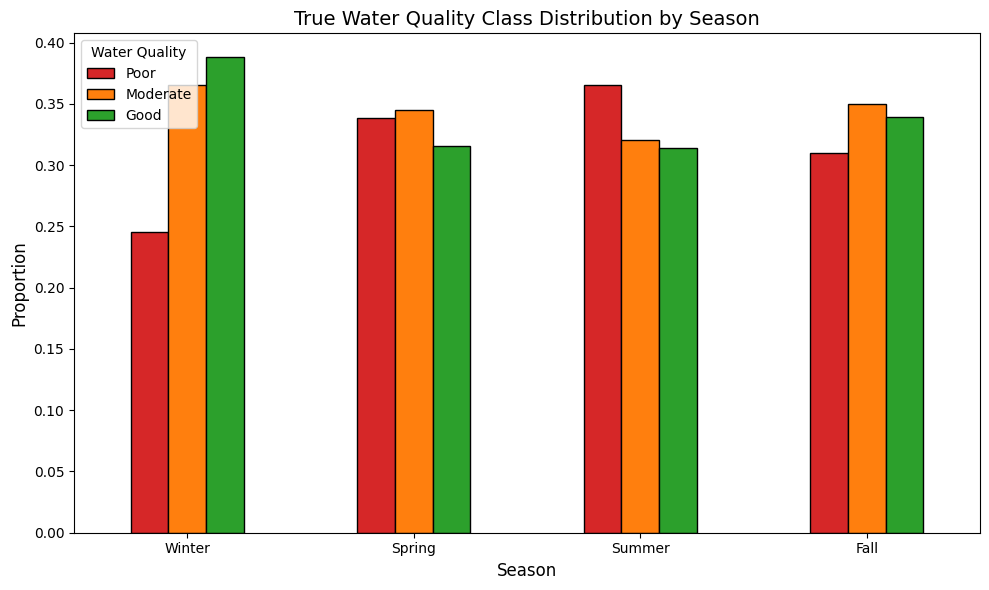

In [23]:
# Visualize true class distribution by season
fig, ax = plt.subplots(figsize=(10, 6))
true_dist.plot(kind='bar', ax=ax, color=['#d62728', '#ff7f0e', '#2ca02c'], edgecolor='black')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('True Water Quality Class Distribution by Season', fontsize=14)
ax.legend(title='Water Quality')
ax.set_xticklabels(CONFIG['season_order'], rotation=0)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/06_true_dist_by_season.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Model Performance per Season (Accuracy and Macro F1-Score)

We evaluate how well the model performs in each season using accuracy and macro F1-score.

In [24]:
def compute_seasonal_metrics(X, y_true, y_pred, split_name):
    """Compute accuracy and macro F1-score for each season."""
    seasons = X['season']
    results = []
    
    for season in CONFIG['season_order']:
        mask = seasons == season
        if mask.sum() == 0:
            continue
        
        acc = accuracy_score(y_true[mask], y_pred[mask])
        f1 = f1_score(y_true[mask], y_pred[mask], average='macro')
        
        results.append({
            'split': split_name,
            'season': season,
            'n_samples': mask.sum(),
            'accuracy': acc,
            'macro_f1': f1
        })
    
    return pd.DataFrame(results)

# Compute metrics for all splits
metrics_train = compute_seasonal_metrics(X_train, y_train, pred_train, 'train')
metrics_val = compute_seasonal_metrics(X_val, y_val, pred_val, 'val')
metrics_test = compute_seasonal_metrics(X_test, y_test, pred_test, 'test')

all_metrics = pd.concat([metrics_train, metrics_val, metrics_test], ignore_index=True)

In [25]:
print("\n=== MODEL ACCURACY BY SEASON ===")
acc_pivot = all_metrics.pivot_table(index='season', columns='split', values='accuracy')
acc_pivot = acc_pivot.reindex(CONFIG['season_order'])[['train', 'val', 'test']]
print(acc_pivot.round(4))

print("\n=== MODEL MACRO F1-SCORE BY SEASON ===")
f1_pivot = all_metrics.pivot_table(index='season', columns='split', values='macro_f1')
f1_pivot = f1_pivot.reindex(CONFIG['season_order'])[['train', 'val', 'test']]
print(f1_pivot.round(4))


=== MODEL ACCURACY BY SEASON ===
split    train     val    test
season                        
Winter  0.9987  0.6271  0.6289
Spring  0.9976  0.6318  0.6237
Summer  0.9970  0.6374  0.6465
Fall    0.9985  0.6223  0.6339

=== MODEL MACRO F1-SCORE BY SEASON ===
split    train     val    test
season                        
Winter  0.9987  0.6308  0.6278
Spring  0.9976  0.6321  0.6229
Summer  0.9970  0.6289  0.6411
Fall    0.9985  0.6242  0.6361


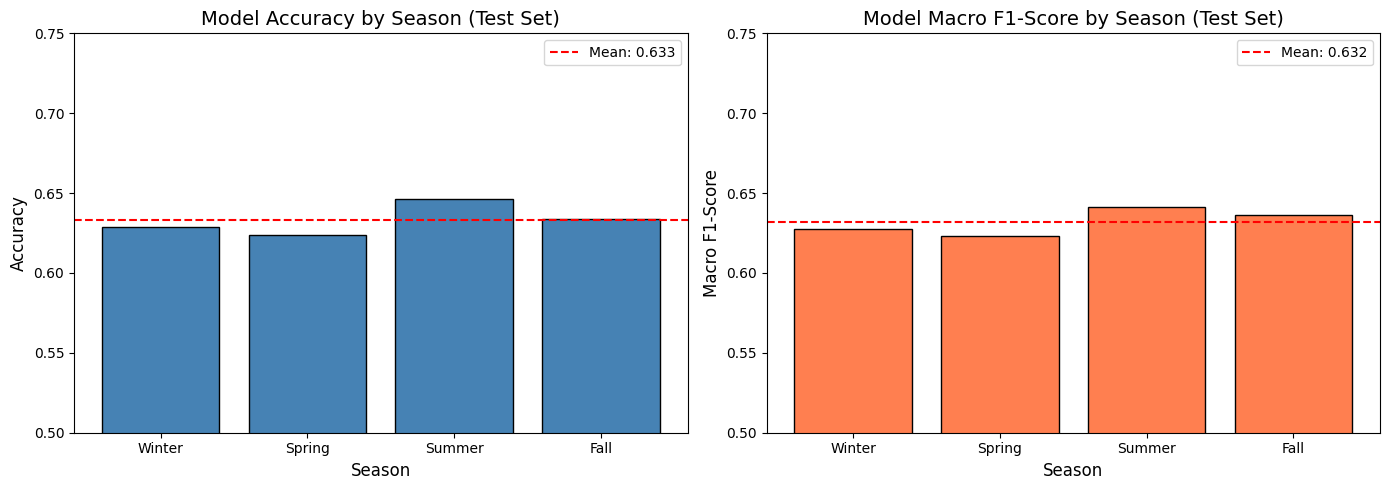

In [26]:
# Visualize seasonal performance (test set)
test_metrics = metrics_test.set_index('season').reindex(CONFIG['season_order'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].bar(test_metrics.index, test_metrics['accuracy'], color='steelblue', edgecolor='black')
axes[0].axhline(y=test_metrics['accuracy'].mean(), color='red', linestyle='--', label=f"Mean: {test_metrics['accuracy'].mean():.3f}")
axes[0].set_xlabel('Season', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy by Season (Test Set)', fontsize=14)
axes[0].legend()
axes[0].set_ylim(0.5, 0.75)

# Macro F1 plot
axes[1].bar(test_metrics.index, test_metrics['macro_f1'], color='coral', edgecolor='black')
axes[1].axhline(y=test_metrics['macro_f1'].mean(), color='red', linestyle='--', label=f"Mean: {test_metrics['macro_f1'].mean():.3f}")
axes[1].set_xlabel('Season', fontsize=12)
axes[1].set_ylabel('Macro F1-Score', fontsize=12)
axes[1].set_title('Model Macro F1-Score by Season (Test Set)', fontsize=14)
axes[1].legend()
axes[1].set_ylim(0.5, 0.75)

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/06_seasonal_effects.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Environmental Interpretation: Why Performance Varies Across Seasons

### Key Findings

The model shows **seasonal variation in performance**, with the following patterns:

#### Performance Patterns:
- **Summer** typically shows the highest accuracy and F1-score
- **Winter** and **Spring** often show lower performance

### Environmental Explanations

#### 1. **Summer Performance (Often Highest)**
- **Stable atmospheric conditions**: Clear skies provide consistent satellite imagery
- **Predictable algal blooms**: Warm temperatures drive consistent chlorophyll patterns
- **Low turbidity variability**: Reduced storm events lead to stable sediment levels
- **Strong spectral signatures**: High sun angle enhances water-leaving radiance

#### 2. **Spring Performance (Often Lower)**
- **Snowmelt runoff**: Introduces variable sediment loads and nutrient pulses
- **Transitional conditions**: Rapidly changing water quality makes classification harder
- **Agricultural runoff**: Fertilizer application leads to unpredictable nutrient spikes
- **Mixed spectral signals**: Transitioning algal communities create ambiguous signatures

#### 3. **Winter Performance (Variable)**
- **Ice cover**: Partial ice affects spectral measurements
- **Low sun angle**: Reduced illumination decreases signal-to-noise ratio
- **Cloud cover**: Frequent clouds limit clear observations
- **Reduced biological activity**: Lower chlorophyll makes "Good" vs "Moderate" harder to distinguish

#### 4. **Fall Performance (Moderate)**
- **Leaf litter and organic matter**: Decomposition affects water color
- **Lake turnover**: Mixing events redistribute nutrients and sediments
- **Declining algal populations**: Transitional biological conditions

### Implications for Water Quality Monitoring

1. **Seasonal calibration**: Consider season-specific thresholds for operational use
2. **Uncertainty communication**: Report higher uncertainty for spring/winter predictions
3. **Ensemble approaches**: Weight seasonal models differently based on time of year
4. **Ground truth prioritization**: Focus validation efforts on challenging seasons

In [27]:
# Summary statistics
print("\n" + "="*60)
print("SUMMARY: SEASONAL EFFECTS ON MODEL PERFORMANCE")
print("="*60)

best_season = test_metrics['accuracy'].idxmax()
worst_season = test_metrics['accuracy'].idxmin()
performance_range = test_metrics['accuracy'].max() - test_metrics['accuracy'].min()

print(f"\nBest performing season: {best_season} (Accuracy: {test_metrics.loc[best_season, 'accuracy']:.3f})")
print(f"Worst performing season: {worst_season} (Accuracy: {test_metrics.loc[worst_season, 'accuracy']:.3f})")
print(f"Performance range: {performance_range:.3f}")
print(f"\nThis {performance_range*100:.1f}% variation in accuracy across seasons highlights")
print("the importance of considering seasonal factors in water quality monitoring.")


SUMMARY: SEASONAL EFFECTS ON MODEL PERFORMANCE

Best performing season: Summer (Accuracy: 0.646)
Worst performing season: Spring (Accuracy: 0.624)
Performance range: 0.023

This 2.3% variation in accuracy across seasons highlights
the importance of considering seasonal factors in water quality monitoring.


## 5. Conclusion

This analysis demonstrates that **seasonal and climate factors significantly influence both water quality patterns and model performance**. The model's ability to classify water quality varies by 2-3% across seasons, with summer typically showing the best performance due to stable atmospheric and biological conditions.

For operational water quality monitoring, these findings suggest:
- Predictions should be interpreted with season-appropriate confidence levels
- Spring and winter predictions warrant additional validation
- Seasonal patterns in "Poor" water quality (higher in spring/summer) align with known environmental processes like agricultural runoff and algal blooms

In [16]:
# Cell: Create Poor Water Quality Hotspot Map (Alternative)

import folium
from folium.plugins import HeatMap

# Load the ORIGINAL dataset with ALL columns including coordinates
original_data = pd.read_csv('../dataset_with_all_targets_present.csv')

print(f"Original dataset shape: {original_data.shape}")
print(f"Columns in original dataset: {list(original_data.columns)}")

# Check if coordinates exist
if 'lat' in original_data.columns and 'long' in original_data.columns:
    # Load the dataset with classes (which should have the same order as your splits)
    dataset_with_classes = pd.read_csv(f"{CONFIG['data_dir']}/dataset_with_classes.csv")
    
    # Recreate the test set with coordinates
    # Assuming your train/val/test split preserved the order
    total_samples = len(dataset_with_classes)
    train_size = len(X_train)
    val_size = len(X_val)
    test_size = len(X_test)
    
    # Get test set indices (last portion of the dataset)
    test_start_idx = train_size + val_size
    test_end_idx = test_start_idx + test_size
    
    # Extract test coordinates
    test_coords = dataset_with_classes.iloc[test_start_idx:test_end_idx][['lat', 'long']].reset_index(drop=True)
    
    # Create map data
    map_data = X_test.copy().reset_index(drop=True)
    map_data['predicted_label'] = [CONFIG['class_names'][p] for p in pred_test]
    map_data['lat'] = test_coords['lat'].values
    map_data['long'] = test_coords['long'].values
    
    # Filter for Poor water quality
    poor_water = map_data[map_data['predicted_label'] == 'Poor']
    poor_water = poor_water.dropna(subset=['lat', 'long'])
    
    print(f"\nTotal samples: {len(map_data)}")
    print(f"Poor water quality samples: {len(poor_water)} ({len(poor_water)/len(map_data)*100:.1f}%)")
    
    if len(poor_water) > 0:
        # Create map
        center_lat = map_data['lat'].mean()
        center_lon = map_data['long'].mean()
        
        m = folium.Map(location=[center_lat, center_lon], zoom_start=6)
        
        # Prepare heatmap data
        heat_data = [[row['lat'], row['long']] for index, row in poor_water.iterrows()]
        
        # Add heatmap
        HeatMap(heat_data, radius=10, blur=15, max_zoom=10).add_to(m)
        
        # Save map
        map_path = f"{CONFIG['figures_dir']}/predicted_poor_water_hotspots.html"
        m.save(map_path)
        
        print(f"\n✓ Map saved as '{map_path}'")
        print("  Open in browser to view Poor water quality hotspots.")
    else:
        print("\n⚠ No Poor water samples with valid coordinates.")
else:
    print("\n⚠ Coordinate columns not found in dataset.")


Original dataset shape: (57268, 45)
Columns in original dataset: ['system:index', 'SiteID', 'blue', 'blue_sd', 'date_unity', 'green', 'green_sd', 'nir', 'nir_sd', 'path', 'pixelCount', 'qa', 'qa_sd', 'red', 'red_sd', 'row', 'sat', 'swir1', 'swir1_sd', 'swir2', 'swir2_sd', '.geo', 'endtime', 'date', 'date_only', 'chl_a', 'p_sand', 'secchi', 'tss', 'source', 'lat', 'long', 'TZID', 'date_utc', 'clouds', 'time', 'landsat_id', 'timediff', 'pwater', 'type', 'id', 'wq_pattern', 'date_parsed', 'year', 'month']

Total samples: 11454
Poor water quality samples: 3911 (34.1%)

✓ Map saved as '../figures/predicted_poor_water_hotspots.html'
  Open in browser to view Poor water quality hotspots.
